#### Part 1: Raw Data Extraction (ETL Pipeline)
*Note: The Python code below parses the raw 30GB+ Lichess `.zst` database. It is included here for methodological transparency. Because of the massive file size and processing time, it is not meant to be executed live during review.* 

*Please skip to **Part 2** to load the pre-processed CSV dataset.*

In [1]:

import zstandard as zstd 
import io
import chess
import chess.pgn
import pandas as pd
import re


def extract_time_pressure_data(game):
    '''
    Extracts useful data from a python chess game 
    '''

    # Extract relevant data from the game headers
    game_id = game.headers.get("Site", None)
    white_elo = game.headers.get("WhiteElo", None)
    black_elo = game.headers.get("BlackElo", None) 
    time_control = game.headers.get("TimeControl", "Unknown") 
    event_Type = game.headers.get("Event", "Unknown")

    # Isolates the time increment to find the true time spent on each move
    increment = 0
    if '+' in time_control: 
        increment = int(time_control.split('+')[1]) 

    game_move_list = [] 

   # Iterate through each move in the game and extract relevant data
    for nodes in game.mainline():
       time_left = nodes.clock() 
       POVeval = nodes.eval() 
       plmoves = nodes.ply()  
       full_move = (plmoves + 1) // (2) 

       if plmoves % 2 == 1:  
            player_colour = "White" 
       else:
            player_colour = "Black" 
            
       # Extract the evaluation score from stockfish if available, otherwise set to None
       if POVeval is not None: 
           move_eval = POVeval.white().score(mate_score=10000)
       else:
            move_eval = None 
           
       # Only keep rows where the clock data is available
       if time_left is not None: 
            move_data = (
                game_id, 
                white_elo, 
                black_elo, 
                player_colour, 
                full_move, 
                time_left, 
                increment, 
                move_eval,
                event_Type
            )
            

            game_move_list.append(move_data) 
    return game_move_list
   

def lichess_pgn(file_path, max_games_to_parse):

   '''
   Decompresses a zstd lichess pgn file and extracts relevant data from each game, returning a pandas dataframe
   '''
   decomp = zstd.ZstdDecompressor()
   games = [] 
   games_parsed = 0

   with open(file_path, 'rb') as zstdcompfile: 
    with decomp.stream_reader(zstdcompfile) as compfile:
        text_stream = io.TextIOWrapper(compfile, encoding='utf-8')

        while games_parsed < max_games_to_parse: 
            game = chess.pgn.read_game(text_stream)
            if game is None:
                break
            game_moves = extract_time_pressure_data(game) 
            games.extend(game_moves) 
            games_parsed += 1 #

    # Create a pandas dataframe from the extracted game data        
    df = pd.DataFrame(games, columns=[
        "GameID", 
        "WhiteElo", 
        "BlackElo", 
        "PlayerColour", 
        "Move", 
        "TimeLeft (Seconds)", 
        "Increment (Seconds)", 
        "Evaluation",
        "GameType"
    ]) 
    return df

# Execute the ETL pipeline
# lichess_file_path = "lichess_db_standard_rated_2026-07.pgn.zst"
# lichess_df = lichess_pgn(lichess_file_path, max_games_to_parse=50000) 
# lichess_df.to_csv("lichesstp_data.csv", index=False)


#### Part 2: Feature Engineering and Data Cleaning

In [4]:
import pandas as pd
import numpy as np

# Load processed data from CSV file
df = pd.read_csv("lichesstp_data.csv")

# Clean missing evaluation data
df_a = df.dropna(subset=["Evaluation"]).copy()

# Calculating Centipawn loss (difference in evaluation between moves)
df_a['Prev_Eval'] = df_a.groupby('GameID')['Evaluation'].shift(1)
df_a['Centipawn_loss'] = np.where(
    df_a['PlayerColour'] == 'White',
    df_a['Prev_Eval'] - df_a['Evaluation'],  # If White, calculate loss as previous eval minus current eval
    df_a['Evaluation'] - df_a['Prev_Eval']   # If Black, calculate loss as current eval minus previous eval
)

df_a['Centipawn_loss'] = df_a['Centipawn_loss'].clip(lower=0)  # Ensure that Centipawn_loss is non-negative

# Dependent Variable: Blunder (1 if Centipawn_loss >= 300, else 0)
df_a['Blunder'] = np.where(df_a['Centipawn_loss'] >= 300, 1, 0)  # Define a blunder as a loss of more than 300 centipawns

# Time spent on each move (difference in clock time between moves)
df_a['Prev_Clock'] = df_a.groupby(['GameID', 'PlayerColour'])['TimeLeft (Seconds)'].shift(1) # Calculate the previous clock time for each player
df_a['TimeSpent'] = (df_a['Prev_Clock'] - df_a['TimeLeft (Seconds)']) + df_a['Increment (Seconds)'] # Calculate the change in clock time
df_a['TimeSpent'] = df_a['TimeSpent'].clip(lower=0)

# Isolate the Elo of the player making the move
df_a['PlayerElo'] = np.where(
    df_a['PlayerColour'] == 'White', 
    df_a['WhiteElo'], 
    df_a['BlackElo']
)

# Standardise the GameType column to ensure consistency
df_a.loc[df_a['GameType'].str.contains('Blitz', case=False, na=False), 'GameType'] = 'Blitz'
df_a.loc[df_a['GameType'].str.contains('Rapid', case=False, na=False), 'GameType'] = 'Rapid'
df_a.loc[df_a['GameType'].str.contains('Bullet', case=False, na=False), 'GameType'] = 'Bullet' # Overwrite the GameType column based on the Event column
df_a.loc[df_a['GameType'].str.contains('Classical', case=False, na=False), 'GameType'] = 'Classical'

# Create a dynamic time pressure dummy variable
conditions = [
    (df_a['GameType'] == 'Bullet') & (df_a['TimeLeft (Seconds)'] < 10),
    (df_a['GameType'] == 'Blitz') & (df_a['TimeLeft (Seconds)'] < 30),
    (df_a['GameType'] == 'Rapid') & (df_a['TimeLeft (Seconds)'] < 60),
    (df_a['GameType'] == 'Classical') & (df_a['TimeLeft (Seconds)'] < 300)
]

choices = [1, 1, 1, 1]

df_a['TimePressure'] = np.select(conditions, choices, default=0)

df_a.dropna(subset=['WhiteElo', 'BlackElo', 'TimeSpent', 'Centipawn_loss', 'GameType'], inplace=True)  # Drop rows with NaN values in TimeSpent or Centipawn_loss

print(df_a.sample(10))


                               GameID  WhiteElo  BlackElo PlayerColour  Move  \
1204944  https://lichess.org/RfT9KRMY      1339      1346        Black     9   
3281680  https://lichess.org/CmjPW6eB      1188      1242        White    28   
1573953  https://lichess.org/aJiKWke3      1536      1626        White    45   
763368   https://lichess.org/BqjS3njD      1663      1722        White    11   
877478   https://lichess.org/m6XZhCmF       806       746        Black    24   
3061689  https://lichess.org/LSsKIkEV      1630      1615        White    50   
310958   https://lichess.org/QHBgSYF9      1820      1838        White    32   
897323   https://lichess.org/TGMfcW1r      1286      1316        White    13   
259601   https://lichess.org/U6KdlAAN      1910      1893        Black    13   
3085065  https://lichess.org/1Eozajs0      1771      1836        Black    16   

         TimeLeft (Seconds)  Increment (Seconds)  Evaluation GameType  \
1204944                47.0                   

#### Part 3: Econometric Modeling 

In [5]:
import statsmodels.formula.api as smf
import numpy as np

# We are regressing 'Blunder' on 'TimePressure' while controlling for 'PlayerElo'
formula = "Blunder ~ TimePressure * PlayerElo"


model_data = df_a[['Blunder', 'TimePressure', 'PlayerElo']].dropna()
logit_model = smf.logit(formula, data=model_data).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.220736
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Blunder   No. Observations:               324700
Model:                          Logit   Df Residuals:                   324696
Method:                           MLE   Df Model:                            3
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.02352
Time:                        22:51:55   Log-Likelihood:                -71673.
converged:                       True   LL-Null:                       -73399.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.5013      0.030    -50.082      0.000      -1.560      

#### Part 4: Data Visualisation
1. 'Higher they Fall' Graph 
2. 'Raw Blunder rate by game type' Bar Chart

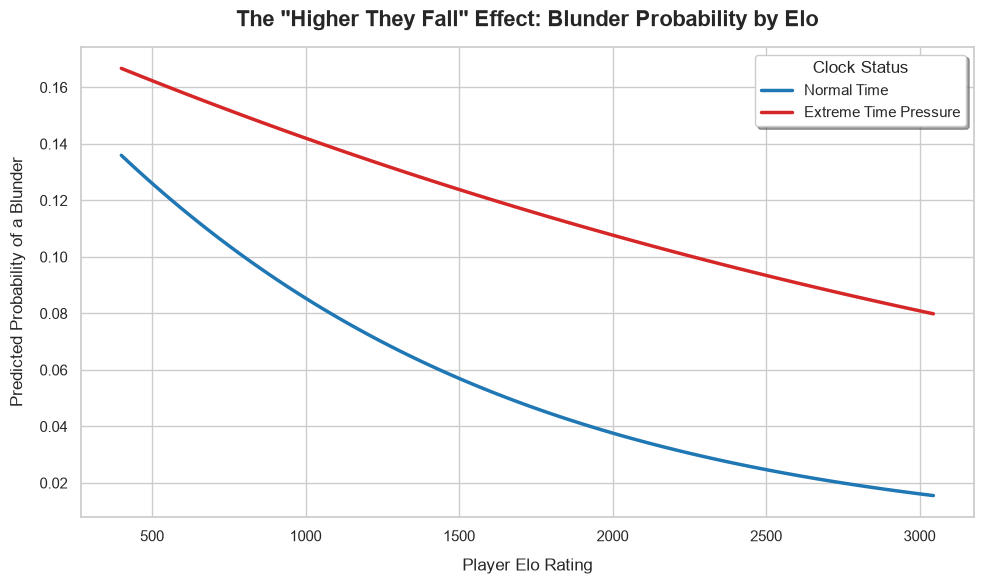

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# We use numpy to create 100 evenly spaced data points between the min and max Elo
elo_range = np.linspace(df_a['PlayerElo'].min(), df_a['PlayerElo'].max(), 100)

# Create two scenario DataFrames to feed into your model
df_normal = pd.DataFrame({'PlayerElo': elo_range, 'TimePressure': 0})
df_pressure = pd.DataFrame({'PlayerElo': elo_range, 'TimePressure': 1})

# Predict the probability of a blunder for both scenarios
df_normal['Predicted_Prob'] = logit_model.predict(df_normal)
df_pressure['Predicted_Prob'] = logit_model.predict(df_pressure)

# Combine the scenarios into one DataFrame for Seaborn
plot_df = pd.concat([df_normal, df_pressure])
plot_df['Condition'] = np.where(plot_df['TimePressure'] == 1, 'Extreme Time Pressure', 'Normal Time')

# Build and style the visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") # Adds a clean, professional background

# Draw the lines
sns.lineplot(
    data=plot_df, 
    x='PlayerElo', 
    y='Predicted_Prob', 
    hue='Condition', 
    palette=['#1f77b4', '#d62728'], # Professional blue and red
    linewidth=2.5
)

# Formatting
plt.title('The "Higher They Fall" Effect: Blunder Probability by Elo', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Player Elo Rating', fontsize=12, labelpad=10)
plt.ylabel('Predicted Probability of a Blunder', fontsize=12, labelpad=10)

# Adjust legend and layout
plt.legend(title='Clock Status', frameon=True, shadow=True)
plt.tight_layout()

#Save the plot 
plt.savefig('htf.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

C:\Users\tolud\AppData\Local\Temp\ipykernel_26796\1379035944.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(new_labels)


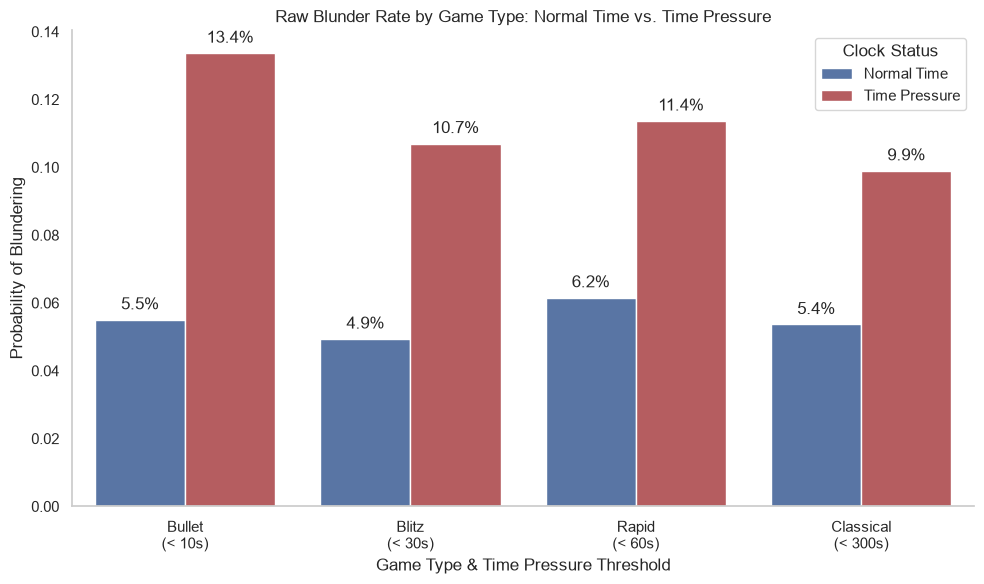

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean blunder rate for each GameType, split by TimePressure
blunder_rates = df_a.groupby(['GameType', 'TimePressure'])['Blunder'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=blunder_rates, 
    x='GameType', 
    y='Blunder', 
    hue='TimePressure', 
    palette=['#4C72B0', '#C44E52'],
    order=['Bullet', 'Blitz', 'Rapid', 'Classical']
)

plt.title('Raw Blunder Rate by Game Type: Normal Time vs. Time Pressure')
plt.xlabel('Game Type & Time Pressure Threshold')
plt.ylabel('Probability of Blundering')

# Update the legend to show text instead of 0 and 1
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Normal Time', 'Time Pressure'], title='Clock Status')


current_labels = [tick.get_text() for tick in ax.get_xticklabels()]

# Explicitly state the time pressure rules on the x-axis
threshold_map = {
    'Bullet': 'Bullet\n(< 10s)',
    'Blitz': 'Blitz\n(< 30s)',
    'Rapid': 'Rapid\n(< 60s)',
    'Classical': 'Classical\n(< 300s)'
}

new_labels = [threshold_map.get(label, label) for label in current_labels]
ax.set_xticklabels(new_labels)

ax.yaxis.grid(False) 

# Remove the top and right border lines of the chart box
sns.despine()

# Display the exact percentages on top of every bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('probofblunder.png', dpi=300, bbox_inches='tight')
plt.show()